# Tutorial 06 | Paul15 — scVI + Palantir + Branch-Separated scJDO

This notebook demonstrates the recommended workflow for branching trajectories:

| Step | Tool | What it does |
|------|------|--------------|
| 1 | scVI | Nonlinear latent space — better geometry than PCA for noisy data |
| 2 | Palantir | Branch-aware pseudotime + per-cell lineage probabilities |
| 3 | `sjd.tl.fit_drift_branches` | scJDO independently per lineage — no mixing |
| 4 | `sjd.pl.*` | Per-branch figures and instability genes |

**Why branch-separated?**  
Standard DPT assigns a single pseudotime to all cells, so at the erythroid/neutrophil
branch point, one pseudotime window contains cells from both lineages. Averaging
their Jacobians mixes two distinct biological programs. Running scJDO per branch
eliminates this — each branch gets its own Jacobian tensor and archetypes.

## Requirements

```bash
pip install scvi-tools    # scVI latent space
pip install palantir      # branch-aware pseudotime
```

In [85]:
#!pip install scvi-tools
#!pip install palantir

In [115]:
import sys, os, warnings
sys.path.insert(0, os.path.abspath('..'))
warnings.filterwarnings('ignore')

# ── Check dependencies ─────────────────────────────────────────────────────
missing = []
for pkg in ['scvi', 'palantir']:
    try:
        __import__(pkg)
        print(f'  {pkg}: OK')
    except ImportError:
        missing.append(pkg)
        print(f'  {pkg}: NOT INSTALLED  →  pip install {"scvi-tools" if pkg=="scvi" else pkg}')

if missing:
    raise SystemExit(
        f'\nInstall missing packages first:\n'
        + '\n'.join(f'  pip install {"scvi-tools" if p=="scvi" else p}' for p in missing)
    )

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scanpy as sc
import scjdo as sjd
import scvi
import palantir

OUTDIR = 'results/06_paul15_scvi_palantir/'
os.makedirs(OUTDIR, exist_ok=True)

# ── Config ──────────────────────────────────────────────────────────────────
N_LATENT      = 20     # scVI latent dimensions
N_SCVI_EPOCHS = 400    # scVI training epochs
N_WAYPOINTS   = 500    # Palantir waypoints
N_ARCHETYPES  = 5      # per-branch archetypes
N_EPOCHS      = 5000   # drift field epochs (50,000 on GPU for publication)
SEED          = 42

print(f'scjdo v{sjd.__version__}')
print(f'scvi    v{scvi.__version__}')
print(f'palantir v{palantir.__version__}')

  scvi: OK
  palantir: OK
scjdo v0.3.0
scvi    v1.3.3
palantir v1.4.4


## Step 1 — Load Paul15 and preserve raw counts

scVI requires raw counts. We store them before log-normalization.

In [116]:
adata = sc.datasets.paul15()
print(f'Loaded: {adata.n_obs} cells x {adata.n_vars} genes')

# Store raw counts BEFORE normalization (scVI requires this)
import scipy.sparse as sp
adata.layers['counts'] = adata.X.copy()

# Standard normalization
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
sc.pp.highly_variable_genes(adata, n_top_genes=2000, flavor='seurat')

# PCA on HVGs — needed for gene-space projection (instability genes, regulators)
# Even though we use scVI for the drift field, PCA loadings (varm['PCs'])
# are required to project Jacobian eigenvectors back to gene space.
sc.tl.pca(adata, n_comps=50, use_highly_variable=True, svd_solver='arpack')
print(f'PCA done: varm["PCs"] shape = {adata.varm["PCs"].shape}')
print(f'HVG selected: {adata.var.highly_variable.sum()} genes')
print('Raw counts stored in adata.layers["counts"]')

Loaded: 2730 cells x 3451 genes
PCA done: varm["PCs"] shape = (3451, 50)
HVG selected: 2000 genes
Raw counts stored in adata.layers["counts"]


## Step 2 — scVI latent space

Train a variational autoencoder that captures nonlinear manifold structure while handling dropout and count noise.

GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Using 2000 HVGs for scVI


Training:   0%|          | 0/400 [00:00<?, ?it/s]

Monitored metric elbo_validation did not improve in the last 20 records. Best score: 1245.426. Signaling Trainer to stop.
(2730, 20)
scVI latent stored: adata.obsm["X_scvi"] shape=(2730, 20)


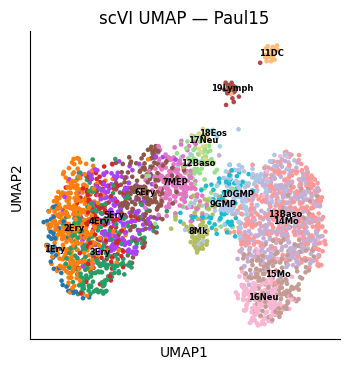

<Figure size 400x400 with 0 Axes>

In [117]:
# Keep only HVGs for scVI
adata_hvg = adata[:, adata.var["highly_variable"]].copy()

print(f"Using {adata_hvg.n_vars} HVGs for scVI")

# Train scVI on HVG-only AnnData
scvi.model.SCVI.setup_anndata(
    adata_hvg,
    layer="counts",
)

model_scvi = scvi.model.SCVI(
    adata_hvg,
    n_latent=N_LATENT,
    n_layers=2,
    n_hidden=128,
    gene_likelihood="nb",
)

model_scvi.train(
    max_epochs=N_SCVI_EPOCHS,
    early_stopping=True,
    early_stopping_patience=20,
    plan_kwargs={"lr": 1e-3},
)

# Store latent representation back in the original adata
adata.obsm["X_scvi"] = model_scvi.get_latent_representation(adata_hvg)

print(adata.obsm["X_scvi"].shape)

# Store latent representation
adata.obsm['X_scvi'] = model_scvi.get_latent_representation()
print(f'scVI latent stored: adata.obsm["X_scvi"] shape={adata.obsm["X_scvi"].shape}')

# Build kNN graph on scVI space
sc.pp.neighbors(adata, use_rep='X_scvi', n_neighbors=15)
sc.tl.umap(adata)

# Visualize
sc.pl.umap(adata, color=['paul15_clusters'], title='scVI UMAP — Paul15',
           legend_loc='on data', legend_fontsize=6, save=False)
plt.savefig(OUTDIR + 'scvi_umap.pdf', dpi=150, bbox_inches='tight')
plt.show()

## Step 3 — Palantir pseudotime + branch probabilities

Palantir computes pseudotime and, critically, a probability for each cell of reaching each terminal state.

In [140]:
# ── Find root cell: cell in 7MEP cluster closest to cluster centroid ────────
mep_mask = (adata.obs['paul15_clusters'] == '7MEP').values
X_lat    = adata.obsm['X_scvi']
centroid = X_lat[mep_mask].mean(0)
dists    = np.linalg.norm(X_lat[mep_mask] - centroid, axis=1)
root_idx  = int(np.flatnonzero(mep_mask)[np.argmin(dists)])
root_cell = adata.obs_names[root_idx]



print(f'Root cell: {root_cell} (cluster: {adata.obs["paul15_clusters"].iloc[root_idx]})')

Root cell: W31173 (cluster: 7MEP)


In [137]:
adata.obs[['paul15_clusters']].drop_duplicates()


,paul15_clusters
W31105,7MEP
W31106,15Mo
W31107,3Ery
W31111,4Ery
W31113,2Ery
W31117,17Neu
W31118,14Mo
W31119,13Baso
W31125,8Mk
W31127,9GMP


In [143]:
import pandas as pd

# ── Identify terminal state cells ────────────────────────────────────────

def _terminal_cell(adata, cluster, rep='X_scvi'):
    mask     = (adata.obs['paul15_clusters'] == cluster).values
    X        = adata.obsm[rep]
    centroid = X[mask].mean(0)
    dists    = ((X[mask] - centroid)**2).sum(1)
    return adata.obs_names[mask][dists.argmin()]

TERMINAL_CLUSTERS = {'erythroid': '1Ery', 'neutrophil': '17Neu'}
terminal_states = pd.Series(
    {name: _terminal_cell(adata, cluster)
     for name, cluster in TERMINAL_CLUSTERS.items()}
)
print('Terminal states:')
for name, cell_id in terminal_states.items():
    print(f'  {name}: {cell_id}  '
          f'(cluster: {adata.obs.loc[cell_id, "paul15_clusters"]})')

# ── Diffusion maps on scVI latent space ───────────────────────────────────
dm_res   = palantir.utils.run_diffusion_maps(
    pd.DataFrame(adata.obsm['X_scvi'], index=adata.obs_names),
    n_components=5,
)
ms_data = palantir.utils.determine_multiscale_space(dm_res)

# Store multiscale eigenvectors in adata so run_palantir can find them
# run_palantir(adata, ...) looks for adata.obsm['DM_EigenVectors_multiscaled']
adata.obsm['DM_EigenVectors_multiscaled'] = ms_data.values

# ── Run Palantir on AnnData — stores results automatically ───────────────

terminal_states = {
    "W31389": "erythroid",
    "W31117": "neutrophil"
}

palantir.core.run_palantir(
    adata,
    root_cell,
    terminal_states=terminal_states,
    num_waypoints=N_WAYPOINTS,
    knn=30,
)

# Stored automatically:
#   adata.obs['palantir_pseudotime']
#   adata.obs['palantir_entropy']
#   adata.obsm['palantir_fate_probabilities']

# Normalize pseudotime to [0,1] for scJDO
pt = adata.obs['palantir_pseudotime'].values.astype('float32')
pt = (pt - pt.min()) / (pt.max() - pt.min() + 1e-8)
adata.obs['pseudotime'] = pt

print(f'Pseudotime range: [{pt.min():.3f}, {pt.max():.3f}]')
print(f'Branches: {list(adata.obsm["palantir_fate_probabilities"].columns)}')

# ── select_branch_cells — assigns cells to branches properly ─────────────
palantir.presults.select_branch_cells(
    adata,
    pseudo_time_key = 'palantir_pseudotime',
    fate_prob_key   = 'palantir_fate_probabilities',
    q=0.01, eps=0.01,
    masks_key       = 'branch_masks',
    save_as_df      = True,
)
masks_df = adata.obsm['branch_masks']
print('\nCells per branch:')
for col in masks_df.columns:
    n = masks_df[col].sum()
    print(f'  {col}: {n} cells ({100*n/len(adata):.0f}%)')

Terminal states:
  erythroid: W38664  (cluster: 1Ery)
  neutrophil: W31354  (cluster: 17Neu)
Sampling and flocking waypoints...
Time for determining waypoints: 5.2420298258463543e-05 minutes
Determining pseudotime...
Shortest path distances using 30-nearest neighbor graph...
Time for shortest paths: 0.008739014466603598 minutes
Iteratively refining the pseudotime...
Correlation at iteration 1: 1.0000
Entropy and branch probabilities...
Markov chain construction...
Computing fundamental matrix and absorption probabilities...
Project results to all cells...
Pseudotime range: [0.000, 1.000]
Branches: ['neutrophil', 'erythroid']

Cells per branch:
  neutrophil: 2662 cells (98%)
  erythroid: 788 cells (29%)


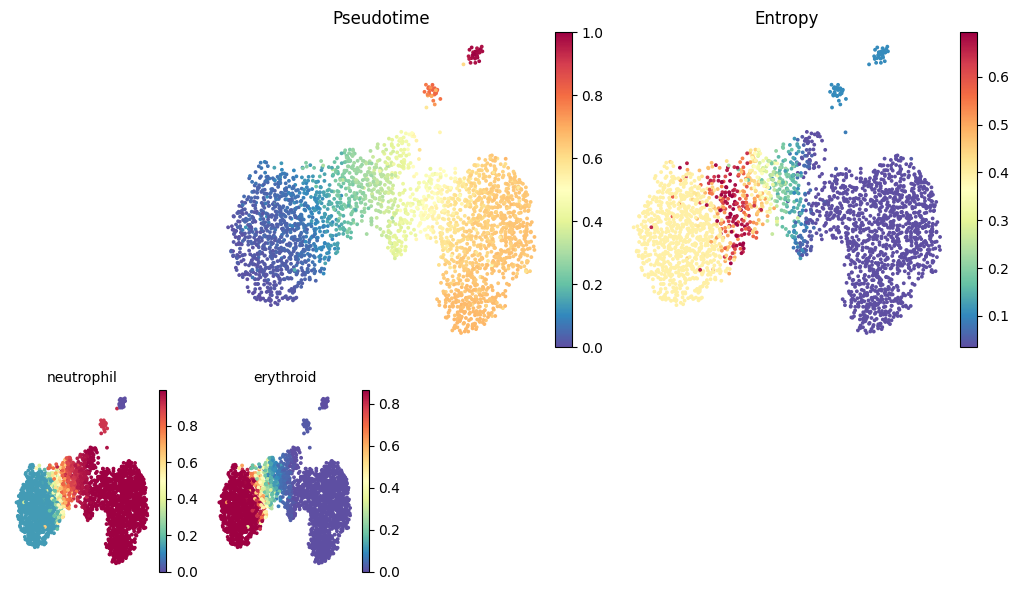

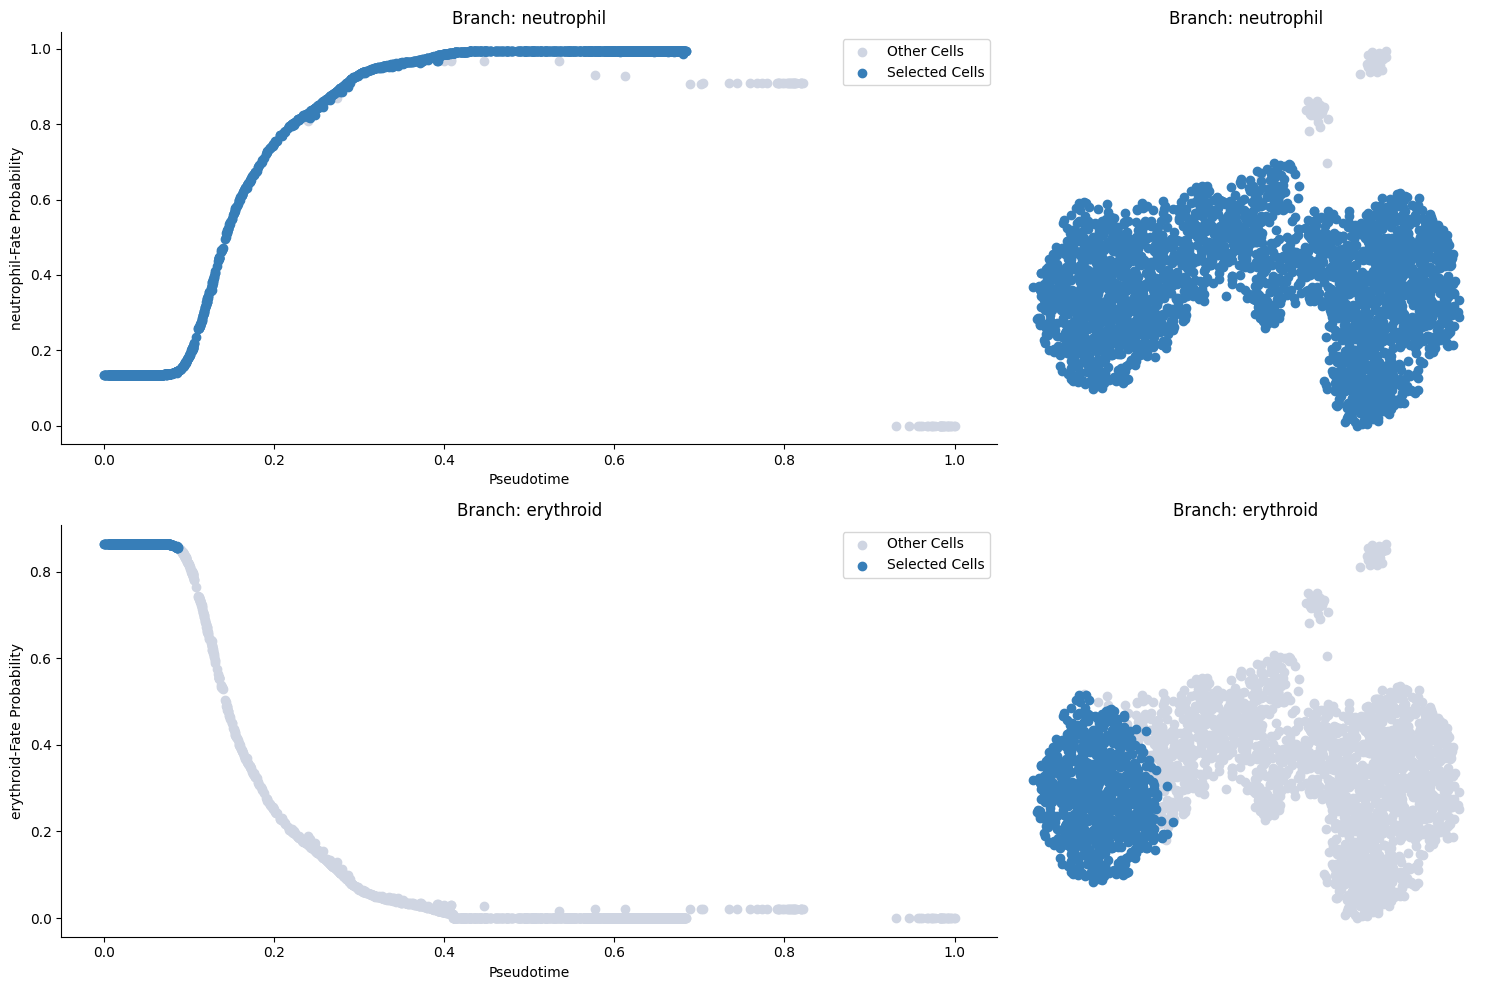

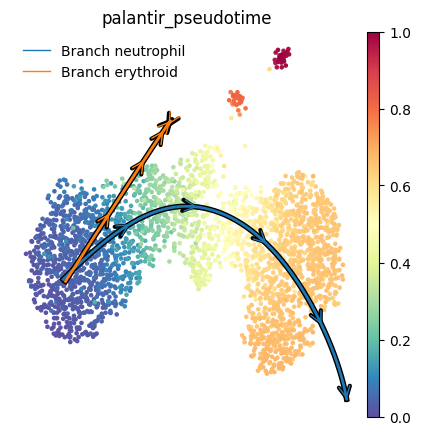

[2026-05-21 16:57:55,104] [INFO    ] Using sparse Gaussian Process since n_landmarks (50) < n_samples (2,662) and rank = 1.0.
[2026-05-21 16:57:55,104] [INFO    ] Using covariance function Matern52(ls=0.9576495289802551).
[2026-05-21 16:57:55,104] [INFO    ] Computing 50 landmarks with k-means clustering (random_state=42).
[2026-05-21 16:57:55,113] [INFO    ] Sigma interpreted as element-wise standard deviation.


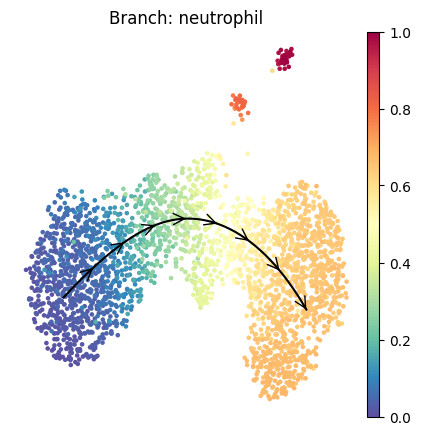

[2026-05-21 16:57:55,251] [INFO    ] Using sparse Gaussian Process since n_landmarks (50) < n_samples (788) and rank = 1.0.
[2026-05-21 16:57:55,252] [INFO    ] Using covariance function Matern52(ls=0.9576495289802551).
[2026-05-21 16:57:55,252] [INFO    ] Computing 50 landmarks with k-means clustering (random_state=42).
[2026-05-21 16:57:55,259] [INFO    ] Sigma interpreted as element-wise standard deviation.


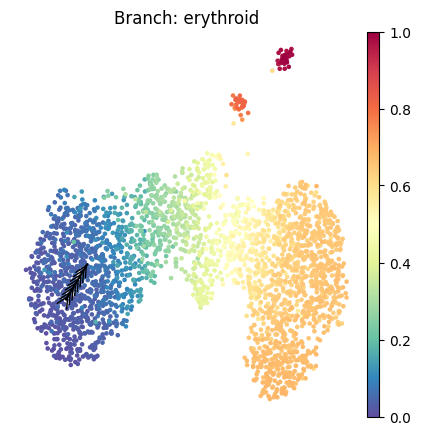

In [144]:
# ── Palantir built-in visualizations ─────────────────────────────────────

# 1. Pseudotime + entropy on UMAP
palantir.plot.plot_palantir_results(adata, s=3)
plt.savefig(OUTDIR + 'palantir_results.pdf', dpi=150, bbox_inches='tight')
plt.show()

# 2. Which cells are selected for each branch
palantir.plot.plot_branch_selection(adata)
plt.savefig(OUTDIR + 'branch_selection.pdf', dpi=150, bbox_inches='tight')
plt.show()

# 3. Smooth trajectory path per branch on UMAP (Palantir style)
palantir.plot.plot_trajectories(adata, pseudotime_interval=(0, 0.95))
plt.savefig(OUTDIR + 'trajectories.pdf', dpi=150, bbox_inches='tight')
plt.show()

# 4. Individual branch trajectories
for branch in adata.obsm['branch_masks'].columns:
    palantir.plot.plot_trajectory(adata, branch,
                                   cell_color='palantir_pseudotime',
                                   n_arrows=8)
    plt.savefig(OUTDIR + f'trajectory_{branch}.pdf', dpi=150, bbox_inches='tight')
    plt.show()

## Step 4 — Branch-separated scJDO

`sjd.tl.fit_drift_branches` runs the full scJDO pipeline independently on
each branch. Each branch gets:
- Its own set of cells (those with branch probability ≥ threshold)
- Its own drift field, trained on branch-specific pseudotime
- Its own Jacobian tensor — no mixing with other branches
- Its own archetypes and instability genes

Results are stored as `adata.uns['scjdo_{branch_name}']`.

In [109]:
# ── Branch-separated scJDO using Palantir branch masks ─────────────────
# branch_masks is a boolean DataFrame: rows=cells, cols=terminal states.
# Each column marks cells on that lineage path (progenitors + committed).
# scJDO runs independently per branch — no cross-lineage Jacobian mixing.

branch_models = sjd.tl.fit_drift_branches(
    adata,
    branch_key       = 'branch_masks',     # Palantir boolean masks
    branch_names     = list(adata.obsm['branch_masks'].columns),
    time_key         = 'pseudotime',
    n_archetypes     = N_ARCHETYPES,
    n_epochs         = N_EPOCHS,
    vel_scale        = 2.0,
    seed             = SEED,
)

print('\nBranch results:')
for name in branch_models:
    key = f'scjdo_{name}'
    r2  = adata.uns[key]['r2']
    n   = adata.uns[key]['n_cells']
    print(f'  {name}: {n} cells, R2={r2:.3f}  -> adata.uns["{key}"]')


Branch: erythroid  (382 cells)
[fit_drift] Using representation: X_pca (latent=pca)
Computing pseudotime-gradient velocity prior...
DriftField: 894,692 parameters | device=cpu | epochs=5000


Training drift field:   0%|          | 0/5000 [00:00<?, ?it/s]

KeyboardInterrupt: 

## Step 5 — Per-branch figures

Generate the full 4-panel summary figure for each branch independently.

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scjdo.tl._drift import _pseudotime_velocity

for branch in branch_models:
    key      = f'scjdo_{branch}'
    cell_idx = np.array(adata.uns[key]['branch_cells'])
    print(f'\n=== {branch} ({len(cell_idx)} cells) ===')

    adata_b = adata[cell_idx].copy()
    adata_b.uns[key] = adata.uns[key]

    # ── Branch-specific drift arrows ──────────────────────────────────────
    # Compute pseudotime velocity ONLY within this branch's cells.
    # In the full dataset, at the branch point, neighbors go two directions
    # and the average arrow points 'between' the branches.
    # Within one branch, ALL higher-pseudotime neighbors go the same way
    # → arrows correctly radiate outward from progenitor along this lineage.
    X_branch  = adata_b.obsm['X_scvi'].astype('float32')  # scVI space
    pt_branch = adata_b.obs['pseudotime'].values.astype('float32')
    V_branch  = _pseudotime_velocity(X_branch, pt_branch, k=15)
    adata_b.obsm['X_velocity_pseudo'] = V_branch

    # Use pre-cached model drift if available
    if 'X_drift' in adata.uns[key]:
        adata_b.obsm['X_drift'] = adata.uns[key]['X_drift']

    res     = adata.uns[key]
    t_np    = res['t_centers']
    max_eig = res['max_real_eig']
    act     = res['act_norm']
    corr    = res['corr_mat']
    K       = act.shape[1]
    ARCH_COLORS = ['#E63946','#2A9D8F','#E9C46A','#457B9D','#8338EC'][:K]

    # ── 4-panel figure ────────────────────────────────────────────────────
    fig = plt.figure(figsize=(14, 10))
    gs  = gridspec.GridSpec(2, 2, hspace=0.42, wspace=0.38,
                            left=0.07, right=0.97, top=0.91, bottom=0.07)
    ax_a = fig.add_subplot(gs[0, 0])
    ax_b = fig.add_subplot(gs[0, 1])
    ax_c = fig.add_subplot(gs[1, 0])
    ax_d = fig.add_subplot(gs[1, 1])

    # Panel a — drift field on UMAP (shows branch structure)
    # Use UMAP if available, PCA as fallback
    plot_basis = 'X_umap' if 'X_umap' in adata_b.obsm else 'X_pca'
    sjd.pl.drift_field(
        adata_b, key=key, basis=plot_basis,
        color='pseudotime',
        velocity_key='X_velocity_pseudo',
        stream=False,        # quiver: reliable on subsets
        n_grid=16,
        min_cells=2,
        ax=ax_a,
    )
    ax_a.set_title(f'a  |  Drift field — {branch} branch\n'
                   f'(velocity computed within {len(cell_idx)} branch cells only)',
                   fontweight='bold', loc='left', fontsize=9)

    # Panel b — local sensitivity
    ax_b.plot(t_np, max_eig, color='black', lw=1.8)
    ax_b.fill_between(t_np, max_eig, 0, where=max_eig>=0.05,
                      alpha=0.30, color='#E63946', label='Sensitive')
    ax_b.fill_between(t_np, max_eig, 0, where=max_eig<=-0.05,
                      alpha=0.20, color='#457B9D', label='Stable')
    ax_b.axhline(0, color='gray', lw=0.8, ls='--')
    ax_b.set_xlabel('Pseudotime'); ax_b.set_ylabel('Max Re(lambda)')
    ax_b.set_title('b  |  Local sensitivity', fontweight='bold', loc='left', fontsize=10)
    ax_b.legend(fontsize=8)

    # Panel c — archetype activation profiles
    for k in range(K):
        ax_c.plot(t_np, act[:, k], color=ARCH_COLORS[k], lw=2, label=f'A{k+1}')
    ax_c.axhline(0, color='gray', lw=0.5, ls='--')
    ax_c.set_xlabel('Pseudotime'); ax_c.set_ylabel('Norm. activation')
    ax_c.set_title(f'c  |  Archetype profiles (K={K})',
                   fontweight='bold', loc='left', fontsize=10)
    ax_c.legend(ncol=K, fontsize=8)

    # Panel d — coordination heatmap
    im = ax_d.imshow(corr, vmin=-1, vmax=1, cmap='RdBu_r', aspect='auto')
    ax_d.set_xticks(range(K)); ax_d.set_xticklabels([f'A{k+1}' for k in range(K)])
    ax_d.set_yticks(range(K)); ax_d.set_yticklabels([f'A{k+1}' for k in range(K)])
    for i in range(K):
        for j in range(K):
            ax_d.text(j, i, f'{corr[i,j]:+.2f}', ha='center', va='center',
                      fontsize=7, color='white' if abs(corr[i,j])>0.6 else 'black')
    plt.colorbar(im, ax=ax_d, label='Temporal r', fraction=0.046, pad=0.04)
    ax_d.set_title('d  |  Coordination', fontweight='bold', loc='left', fontsize=10)

    fig.suptitle(f'scJDO — {branch} lineage  (R2={res["r2"]:.3f})',
                 fontsize=12, fontweight='bold')
    save_path = OUTDIR + f'figure_{branch}.pdf'
    fig.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    plt.close(fig)
    print(f'Saved: {save_path}')

## Step 6 — Per-branch instability genes

Which genes drive local instability in each lineage?

In [ ]:
gene_tables = {}

for branch in branch_models:
    key = f'scjdo_{branch}'
    cell_idx = adata.uns[key]['branch_cells']
    adata_b  = adata[cell_idx].copy()
    adata_b.uns[key]   = adata.uns[key]
    if 'PCs' in adata.varm:
        adata_b.varm['PCs'] = adata.varm['PCs']

    print(f'\n{"="*55}')
    print(f'Branch: {branch}  ({adata.uns[key]["n_cells"]} cells)')
    print(f'{"="*55}')

    table = sjd.pl.instability_genes(
        adata_b,
        key     = key,
        n_genes = 15,
        save    = OUTDIR + f'instability_genes_{branch}.pdf',
    )
    gene_tables[branch] = table
    table.to_csv(OUTDIR + f'instability_genes_{branch}.csv', index=False)

## Step 7 — Regulatory network per branch

Which TFs drive instability specifically in the erythroid vs myeloid program?

In [ ]:
reg_tables = {}

for branch in branch_models:
    key      = f'scjdo_{branch}'
    reg_key  = f'scjdo_regulators_{branch}'
    cell_idx = adata.uns[key]['branch_cells']
    adata_b  = adata[cell_idx].copy()
    adata_b.uns[key]    = adata.uns[key]
    if 'PCs' in adata.varm:
        adata_b.varm['PCs'] = adata.varm['PCs']

    df_reg = sjd.tl.infer_regulators(
        adata_b,
        key       = key,
        organism  = 'mouse',
        n_top     = 15,
        key_added = reg_key,
        verbose   = False,
    )
    reg_tables[branch] = df_reg
    df_reg.to_csv(OUTDIR + f'regulators_{branch}.csv', index=False)

    sjd.pl.regulator_network(
        adata_b,
        key         = reg_key,
        scjdo_key = key,
        n_tfs       = 5,
        n_targets   = 6,
        save        = OUTDIR + f'regulator_network_{branch}.pdf',
    )

    print(f'{branch} top 5 regulators: {df_reg["regulator"].head(5).tolist()}')

## Step 8 — Cross-branch comparison

Which instability genes and regulators are branch-specific vs shared?

In [ ]:
branches = list(branch_models.keys())

# ── Instability gene comparison ──────────────────────────────────────────
gene_sets = {b: set(gene_tables[b]['gene'].tolist()) for b in branches}

print('INSTABILITY GENES — cross-branch comparison')
print('=' * 55)
for b in branches:
    others  = [gene_sets[o] for o in branches if o != b]
    unique  = gene_sets[b] - set.union(*others) if others else gene_sets[b]
    uniq_str = ', '.join(sorted(unique)[:10])
    print(f'{b}-specific ({len(unique)}): {uniq_str}')

shared = set.intersection(*gene_sets.values()) if len(gene_sets) > 1 else set()
shared_str = ', '.join(sorted(shared)[:10])
print(f'Shared ({len(shared)}): {shared_str}')

# ── Regulator comparison ──────────────────────────────────────────────────
print()
print('REGULATORS — cross-branch comparison')
print('=' * 55)
reg_sets = {b: set(reg_tables[b]['regulator'].tolist()) for b in branches if b in reg_tables}
for b in reg_sets:
    others  = [reg_sets[o] for o in reg_sets if o != b]
    unique  = reg_sets[b] - set.union(*others) if others else reg_sets[b]
    uniq_str = ', '.join(sorted(unique)[:8])
    print(f'{b}-specific ({len(unique)}): {uniq_str}')

if len(reg_sets) > 1:
    shared_reg = set.intersection(*reg_sets.values())
    shared_reg_str = ', '.join(sorted(shared_reg)[:8])
    print(f'Shared ({len(shared_reg)}): {shared_reg_str}')

# ── Sensitivity profile comparison ────────────────────────────────────────
colors = ['#2196F3', '#E63946', '#2A9D8F', '#E9C46A']
fig, ax = plt.subplots(figsize=(8, 3.5))
for k, branch in enumerate(branches):
    key   = f'scjdo_{branch}'
    t_np  = adata.uns[key]['t_centers']
    eig   = adata.uns[key]['max_real_eig']
    n     = adata.uns[key]['n_cells']
    ax.plot(t_np, eig, color=colors[k % len(colors)], lw=2.0,
            label=f'{branch} (n={n})')
ax.axhline(0, color='gray', lw=0.8, ls='--')
ax.set_xlabel('Pseudotime'); ax.set_ylabel('Max Re(lambda)')
ax.set_title('Local sensitivity — per-branch comparison', fontsize=10)
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(OUTDIR + 'sensitivity_comparison.pdf', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: sensitivity_comparison.pdf')

## Step 9 — Save all results